C:\Users\Ishita Jain\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


Accuracy: 90.00%
Patient 1: Actual=Yes, Predicted=No
Patient 2: Actual=Yes, Predicted=Yes


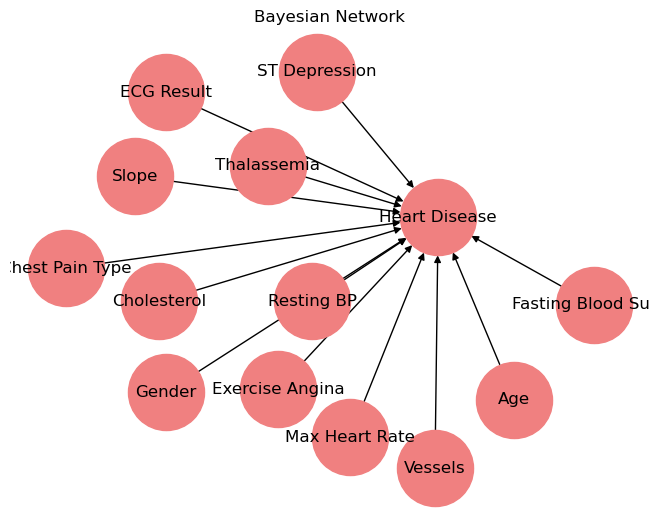

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder, KBinsDiscretizer
from sklearn.metrics import accuracy_score

# Load data
df = pd.read_csv('Heart.csv')

target = 'Heart Disease'
num_cols = ['Age','Resting BP','Cholesterol','Max Heart Rate','ST Depression']

# Encode categorical + target
for col in df.columns:
    if col not in num_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

# Discretize numeric columns
df[num_cols] = KBinsDiscretizer(n_bins=3, encode='ordinal').fit_transform(df[num_cols])

# Train model
X, y = df.drop(columns=[target]), df[target]
model = CategoricalNB().fit(X, y)

# Accuracy
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)*100:.2f}%")

# Demo predictions
for i in [0, 1]:
    print(f"Patient {i+1}: Actual={'Yes' if y[i] else 'No'}, Predicted={'Yes' if y_pred[i] else 'No'}")

# Bayesian Network Graph
G = nx.DiGraph([(col, target) for col in X.columns])
nx.draw(G, with_labels=True, node_size=3000, node_color='lightcoral')
plt.title("Bayesian Network")
plt.show()